In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from catboost import CatBoostClassifier
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline 

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [33]:
!pip install textblob catboost yfinance scikit-learn pandas numpy matplotlib seaborn

In [34]:
np.random.seed(42)
n_samples = 500

dates = pd.date_range(start="2024-01-01", end="2024-12-31", periods=n_samples)
amazon_data = {
    'Review_Date': dates.strftime('%Y-%m-%d'),
    'Price': np.random.uniform(15, 250, n_samples).round(2),
    'is_returned': np.random.choice([0, 1], n_samples, p=[0.75, 0.25])
}
amazon_df = pd.DataFrame(amazon_data)
amazon_df['Review_Date'] = pd.to_datetime(amazon_df['Review_Date'])

reviews_data = []
for idx, row in amazon_df.iterrows():
    is_noisy = np.random.rand() < 0.15
    if (row['is_returned'] == 1 and not is_noisy) or (row['is_returned'] == 0 and is_noisy):
        review_text = np.random.choice([
            "The size is too small, I might have to return it.",
            "Quality is not what I expected, disappointed.",
            "Wrong size sent, but fabric is nice.",
            "A bit damaged on arrival, cheap feel."
        ])
        rating = np.random.randint(1, 4)
    else:
        review_text = np.random.choice([
            "Great fit and amazing fabric!",
            "Love it, perfectly fits my style.",
            "Very good quality for the price.",
            "Fast shipping and nice packaging."
        ])
        rating = np.random.randint(3, 6)
    reviews_data.append({'Review_Text': review_text, 'Rating': rating})

reviews_df = pd.DataFrame(reviews_data)
amazon_df = pd.concat([amazon_df, reviews_df], axis=1)

print("E-ticaret simülasyon verisi hazırlandı.")
amazon_df.head()


E-ticaret simülasyon verisi hazırlandı.


,Review_Date,Price,is_returned,Review_Text,Rating
0,2024-01-01,103.02,0,"Love it, perfectly fits my style.",5
1,2024-01-01,238.42,0,Great fit and amazing fabric!,3
2,2024-01-02,187.02,0,"Love it, perfectly fits my style.",4
3,2024-01-03,155.68,1,"Quality is not what I expected, disappointed.",1
4,2024-01-03,51.66,0,Very good quality for the price.,4


In [35]:
print("-> Yahoo Finance API üzerinden Dolar Endeksi (DXY) verileri canlı çekiliyor...")
dxy_data = yf.download("DX-Y.NYB", start="2024-01-01", end="2025-01-01")


dxy_df = dxy_data[['Close']].reset_index()
dxy_df.columns = [col[0] if isinstance(col, tuple) else col for col in dxy_df.columns]
dxy_df.columns = ['Review_Date', 'DXY_Market_Price']
dxy_df['Review_Date'] = pd.to_datetime(dxy_df['Review_Date'])

merged_df = pd.merge(amazon_df, dxy_df, on='Review_Date', how='left')
merged_df['DXY_Market_Price'] = merged_df['DXY_Market_Price'].ffill().bfill()

print(f"-> Başarılı! Birleştirilen veri seti satır sayısı: {merged_df.shape[0]}")
merged_df.head()

-> Yahoo Finance API üzerinden Dolar Endeksi (DXY) verileri canlı çekiliyor...


[*********************100%***********************]  1 of 1 completed

-> Başarılı! Birleştirilen veri seti satır sayısı: 500


,Review_Date,Price,is_returned,Review_Text,Rating,DXY_Market_Price
0,2024-01-01,103.02,0,"Love it, perfectly fits my style.",5,102.199997
1,2024-01-01,238.42,0,Great fit and amazing fabric!,3,102.199997
2,2024-01-02,187.02,0,"Love it, perfectly fits my style.",4,102.199997
3,2024-01-03,155.68,1,"Quality is not what I expected, disappointed.",1,102.459999
4,2024-01-03,51.66,0,Very good quality for the price.,4,102.459999


In [36]:

merged_df['Sentiment_Score'] = merged_df['Review_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)


def check_complaint(text):
    keywords = ['small', 'broken', 'damaged', 'cheap', 'disappointed', 'return', 'wrong size']
    return 1 if any(word in str(text).lower() for word in keywords) else 0

merged_df['Complaint_Flag'] = merged_df['Review_Text'].apply(check_complaint)

merged_df['Review_Length'] = merged_df['Review_Text'].astype(str).apply(len)
merged_df['Economic_Stress_Index'] = (merged_df['Price'] * merged_df['DXY_Market_Price'] * merged_df['Review_Length']) / (merged_df['Rating'] + 1)

print("-> İş mantığına uygun yeni değişkenler başarıyla türetildi.")
merged_df[['Review_Text', 'Sentiment_Score', 'Complaint_Flag', 'Economic_Stress_Index']].head()



-> İş mantığına uygun yeni değişkenler başarıyla türetildi.


,Review_Text,Sentiment_Score,Complaint_Flag,Economic_Stress_Index
0,"Love it, perfectly fits my style.",0.750,0,57907.540271
1,Great fit and amazing fabric!,0.650,0,176657.293725
2,"Love it, perfectly fits my style.",0.750,0,126148.726633
3,"Quality is not what I expected, disappointed.",-0.425,1,358896.884793
4,Very good quality for the price.,0.910,0,33875.734737


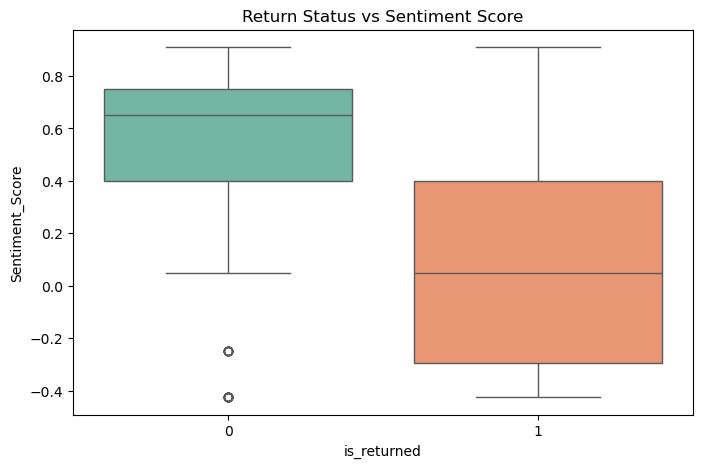

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_returned', y='Sentiment_Score', data=merged_df, palette='Set2')
plt.title('Return Status vs Sentiment Score')
plt.show() 

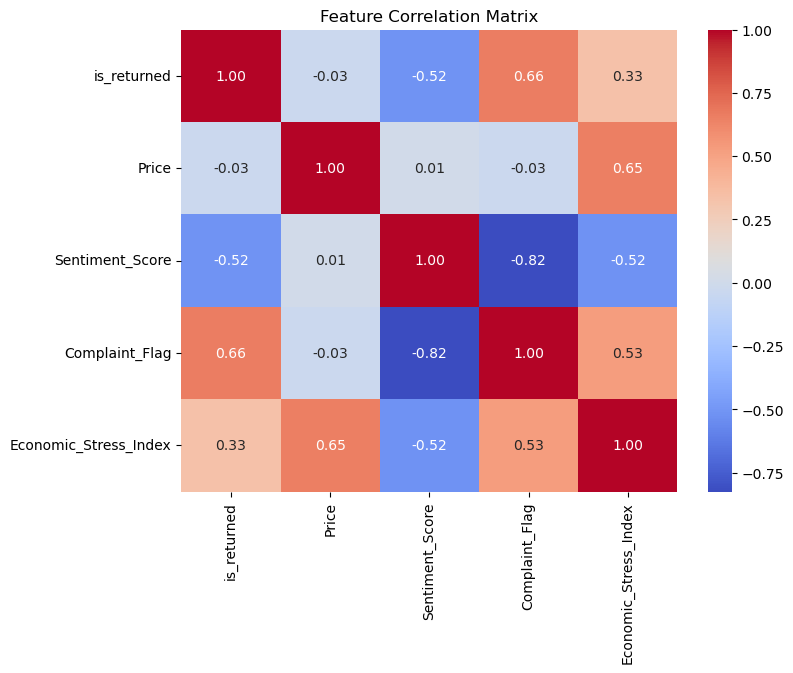

In [38]:
plt.figure(figsize=(8, 6))
corr = merged_df[['is_returned', 'Price', 'Sentiment_Score', 'Complaint_Flag', 'Economic_Stress_Index']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [39]:
features = ['Price', 'Sentiment_Score', 'Complaint_Flag', 'Economic_Stress_Index', 'Review_Length']
X = merged_df[features]
y = merged_df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=5, verbose=0, random_seed=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("[Model Teknik Başarı Raporu]")
print(classification_report(y_test, y_pred))

[Model Teknik Başarı Raporu]
              precision    recall  f1-score   support

           0       0.93      0.83      0.88        78
           1       0.57      0.77      0.65        22

    accuracy                           0.82       100
   macro avg       0.75      0.80      0.77       100
weighted avg       0.85      0.82      0.83       100



[FİNANSAL SİMÜLASYON BULGULARI]
-> Model Yokken Toplam İade Zararı: 3300 TL
-> En Kârlı Eşik Değeri (Threshold): %10
-> Sağlanan Net Tasarruf: 920.00 TL



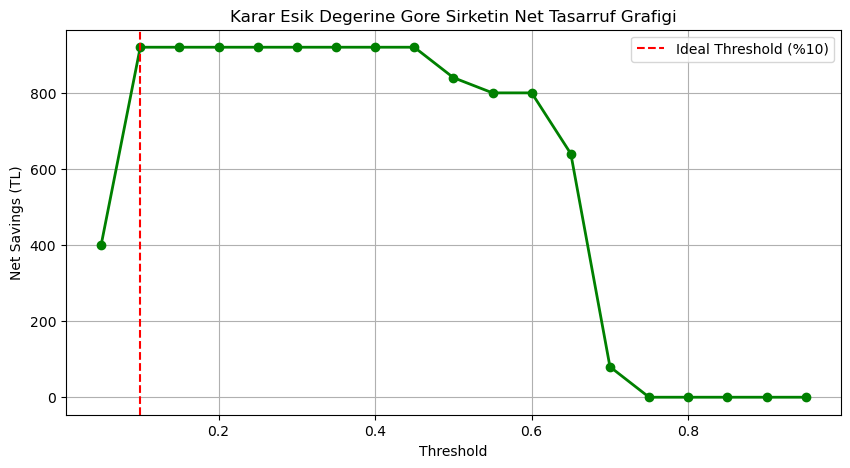

In [40]:
maliyet_iade = 150
maliyet_aksiyon = 40
engelleme_orani = 0.80

esikler = np.linspace(0.05, 0.95, 19)
finansal_sonuclar = []
hiç_mudahale_yok_zarar = y_test.sum() * maliyet_iade

for esik in esikler:
    tahmin_yeni = (y_pred_proba >= esik).astype(int)
    tp = np.sum((y_test == 1) & (tahmin_yeni == 1))
    fp = np.sum((y_test == 0) & (tahmin_yeni == 1))
    fn = np.sum((y_test == 1) & (tahmin_yeni == 0))

    toplam_maliyet = (fn * maliyet_iade) + (tp * (1 - engelleme_orani) * maliyet_iade) + ((tp + fp) * maliyet_aksiyon)
    tasarruf = hiç_mudahale_yok_zarar - toplam_maliyet

    finansal_sonuclar.append({'Threshold': esik, 'Total_Cost': toplam_maliyet, 'Net_Savings': tasarruf})

sim_df = pd.DataFrame(finansal_sonuclar)
en_iyi_senaryo = sim_df.loc[sim_df['Net_Savings'].idxmax()]

print("[FİNANSAL SİMÜLASYON BULGULARI]")
print(f"-> Model Yokken Toplam İade Zararı: {hiç_mudahale_yok_zarar} TL")
print(f"-> En Kârlı Eşik Değeri (Threshold): %{en_iyi_senaryo['Threshold'] * 100:.0f}")
print(f"-> Sağlanan Net Tasarruf: {en_iyi_senaryo['Net_Savings']:.2f} TL\n")

# Net Tasarruf Grafiği
plt.figure(figsize=(10, 5))
plt.plot(sim_df['Threshold'], sim_df['Net_Savings'], marker='o', color='green', linewidth=2)
plt.axvline(en_iyi_senaryo['Threshold'], color='red', linestyle='--',
            label=f"Ideal Threshold (%{en_iyi_senaryo['Threshold'] * 100:.0f})")
plt.title('Karar Esik Degerine Gore Sirketin Net Tasarruf Grafigi')
plt.xlabel('Threshold')
plt.ylabel('Net Savings (TL)')
plt.grid(True)
plt.legend()
plt.show()

In [1]:
import os
print(os.getcwd());

C:\Users\pc
